# Example of treatments available

This notebook shows how to use some extra features for your gridmarthe treatments


In [1]:
# import modules
import numpy as np
import gridmarthe as gm
import matplotlib.pyplot as plt

In [2]:
grid = gm.load_marthe_grid('./data/craie_npc.permh', drop_nan=True)  # NaN needs to be drop or set (change 0 to nan for permh for example)
grid

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 1, zone: 101209)
Coordinates:
  * time     (time) datetime64[ns] 8B 1850-01-01
  * zone     (zone) int32 405kB 47402 47403 47763 ... 2381150 2381151 2381457
Data variables:
    permeab  (time, zone) float64 810kB 1e-05 1e-05 1e-05 ... 0.0001 0.0001
    x        (zone) float32 405kB 6.372e+05 6.378e+05 ... 6.382e+05 6.38e+05
    y        (zone) float32 405kB 2.617e+06 2.617e+06 ... 2.592e+06 2.592e+06
    dx       (zone) float32 405kB 500.0 500.0 500.0 500.0 ... 100.0 100.0 100.0
    dy       (zone) float32 405kB 500.0 500.0 500.0 500.0 ... 100.0 100.0 100.0
    z        (zone) int32 405kB 1 1 1 1 1 1 1 1 1 1 1 ... 9 9 9 9 9 9 9 9 9 9 9
Attributes: (12/17)
    conventions:          CF-1.10
    title:                
    marthe_grid_version:  9.0
    original_dimensions:  x,y,z [grids]: 387 304 10; 307 442 10
    lon_resolution:       100.0, 500.0
    lat_resolution:       100.0, 500.0
    ...                   ...
    creation_date:        Created on 2025-03-26T13:40:44Z UTC
    institution:          BRGM, French Geological Survey, Orléans, France
    comment:              Hydrogeological model created with MARTHE code (Thi...
    resolution_units:     m
    projection:           epsg:27572
    domain:               FR-France

## Get surface mask

In [3]:
surf = gm.get_surface_layer(grid)
surf

<xarray.Dataset> Size: 841kB
Dimensions:  (zone: 21025)
Coordinates:
  * zone     (zone) int32 84kB 178171 177784 647989 ... 1389346 1660427 1660120
Data variables:
    time     (zone) datetime64[ns] 168kB 1850-01-01 1850-01-01 ... 1850-01-01
    permeab  (zone) float64 168kB 1e-06 1e-06 0.003068 ... 1e-06 2e-05 2e-05
    x        (zone) float32 84kB 6.188e+05 6.188e+05 ... 6.494e+05 6.494e+05
    y        (zone) float32 84kB 2.6e+06 2.6e+06 ... 2.606e+06 2.606e+06
    dx       (zone) float32 84kB 500.0 500.0 500.0 500.0 ... 100.0 100.0 100.0
    dy       (zone) float32 84kB 500.0 500.0 500.0 500.0 ... 100.0 100.0 100.0
    z        (zone) int32 84kB 2 2 6 6 8 8 8 8 5 2 6 6 ... 2 2 2 2 2 2 2 2 2 4 4

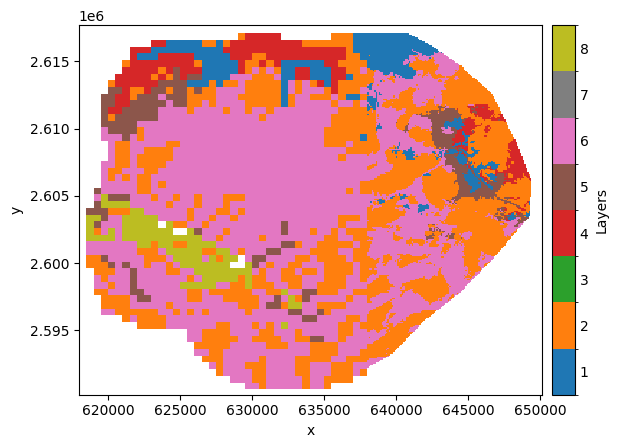

In [6]:
# xarray version
toto = gm.assign_coords(surf, add_lay=False) # add lay false because it needs to be a variable to plot, not a dimension
gm.plot_outcrop(toto)
plt.show()

This function also allow user to get the value of a variable in the surface layer,
or a subset of aquifer layers.

For example, to get the value of your variable (groundwater head for example) in
the first layer encountered between 3 layers:

In [ ]:
head_surf = gm.get_surface_layer(grid, aquif_layers=[6,8,9])  # get the values in the first layer between layers 6, 8 and 9

## Get mask of active domain

In [7]:
mask = gm.get_active_mask(grid) # return a geopandas geodataframe

/home/manlaya/envs/gm/lib/python3.11/site-packages/gridmarthe/operasem/gis.py:58: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if 'time' in ds.dims.keys():


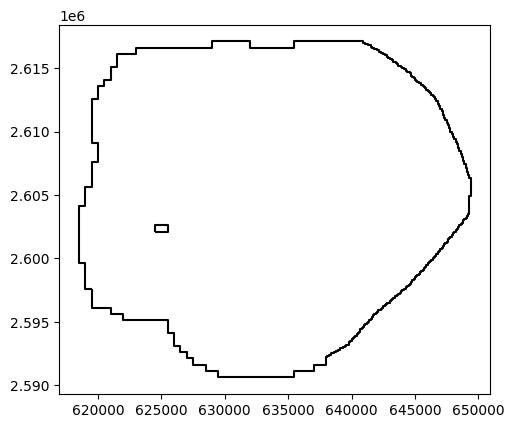

In [8]:
mask.boundary.plot(color='k')
plt.show()

## Compute depths and thickness

Users can get geometry attributes (depth, thickness, upper/lower altitudes) in a dataset:

In [1]:
topo = gm.load_marthe_grid('./data/example.topog')   # be careful with nan here, topography can be set outside of active area
hsubs = gm.load_marthe_grid('./data/example.hsubs')  # same here, hsubs can be set outside of active area
geom = gm.compute_geometry(topo, hsubs)
# print(geom.where(~geom['depth'].isnull(), drop=True))
geom


NameError: name 'gm' is not defined

## Interpolation, regridding, transformations

### Regrid (coarse/refine resolution)

In [ ]:
# Tutorial in construction

### Projection transformation
